# PSO for Perceptual Image Denoising
Given noisy image $v$, find $\hat{u}$ minimising:
$$\mathcal{L}_p(\hat{u}_p) = 1 - \text{SSIM}(\hat{u}_p, v_p) + \lambda \cdot \text{TV}(\hat{u}_p), \quad \hat{u}_k \in [0,1]$$
Strategy: split into patches, optimise each independently in parallel, stitch back.

In [133]:
# libraries
import numpy as np
import matplotlib.pyplot as plt
import random
from skimage.metrics import structural_similarity as ssim
from skimage import util
from PIL import Image
import pyswarms
import time
import multiprocess as multiprocessing

In [135]:
# parameters
patch_shape = (16, 16)

n_particles = 20
n_iter = 100

tv_lambda = 0.1
w_inertia = 0.7
c1_cognitive = 1.5
c2_social = 1.5

### 1 – Preprocessing

Image format, size, color mode: (None, (512, 512), 'L')
Shape of patched image: (32, 32, 16, 16)
Patch shape: (16, 16)


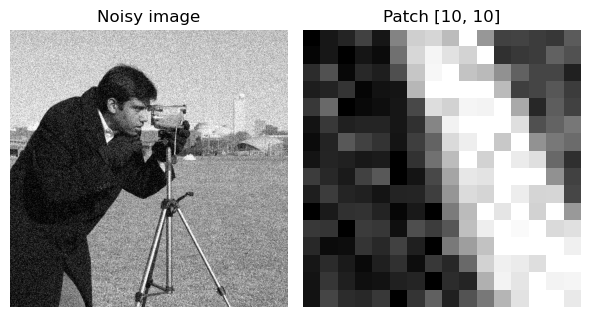

In [100]:
# convert to grayscale (without: PNG (512, 512) RGBA)
with Image.open("noisy_image.png") as im:
    im_grey = im.convert("L")
print(f"Image format, size, color mode: {im_grey.format, im_grey.size, im_grey.mode}")

# normalize 
im_n = np.array(im_grey)/255

# divide image into patches
patches_im_n = util.view_as_blocks(im_n, patch_shape)
print(f"Shape of patched image: {patches_im_n.shape}")

# select a patch for workflow development
v_patch = patches_im_n[10, 10]
print(f"Patch shape: {v_patch.shape}")

# visualize image and selected patch
fig, axes = plt.subplots(1, 2, figsize=(6, 4))
axes[0].imshow(im_n, cmap="gray")
axes[0].set_title("Noisy image")
axes[0].axis("off")

axes[1].imshow(v_patch, cmap="gray")
axes[1].set_title("Patch [10, 10]")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 1.2 – Total variation (TV) and objective function
$$\text{TV}(\hat{u}) = \sum_{i,j} \sqrt{(\hat{u}_{i+1,j} - \hat{u}_{i,j})^2 + (\hat{u}_{i,j+1} - \hat{u}_{i,j})^2}$$
Given noisy image $v$, find $\hat{u}$ minimising:
$$\mathcal{L}_p(\hat{u}_p) = 1 - \text{SSIM}(\hat{u}_p, v_p) + \lambda \cdot \text{TV}(\hat{u}_p), \quad \hat{u}_k \in [0,1]$$

In [81]:
# compute difference between each pixel and its right resp. bottom neighbour, drop last column resp. row to address shape differences, then compute TV
def tv(u_patch):
    diff_down = u_patch[1:, :-1] - u_patch[:-1, :-1]
    diff_right = u_patch[:-1, 1:] - u_patch[:-1, :-1]
    return np.sum(np.sqrt(diff_down**2 + diff_right**2))

def loss(u_patch, v_patch):
    ssim_patch = ssim(u_patch, v_patch, data_range = 1.0, full=False, gradient=False)
    return 1.0 - float(ssim_patch) + tv_lambda*tv(u_patch)

In [80]:
# check (0-0 + 0.1 x 46.1)
tv(v_patch)
loss(v_patch, v_patch)

np.float64(46.1332567152585)

### 2 — PSO (manual)
$$v_i^{t+1} = w \cdot v_i^t + c_1 r_1 (p_i - x_i^t) + c_2 r_2 (g - x_i^t)$$
$$x_i^{t+1} = x_i^t + v_i^{t+1}$$

  - One particle = one candidate denoised patch, flattened to 256 pixel values (one 
  row of x)                                                                         
  - Position of a particle = those 256 pixel values, each in [0,1]                  
  - Velocity of a particle = how much each pixel value changes per iteration — a    
  direction and speed in the 256-dim space                                          
  - Personal best p[i] = the best (lowest loss) position particle i has ever visited
  - Global best g = the best position any particle has ever visited across the whole
   swarm 

In [136]:
#   # initialise swarm: positions, velocities, losses, personal bests, global best                     
v_patch_flat = v_patch.flatten()
u_particles = np.random.uniform(size = (n_particles, v_patch_flat.size))
u_velocity = np.random.uniform(-0.1, 0.1, size = (n_particles, v_patch_flat.size))

u_patches = u_particles.reshape(n_particles, *patch_shape)
scores = np.array([loss(u_patch, v_patch) for u_patch in u_patches], dtype = float)

u_best_p = u_particles.copy()
u_best_scores = scores.copy()
g_best_p = u_best_p[np.argmin(u_best_scores)]
g_best_scores = np.min(u_best_scores)

#### Particle swarm optimization loop

  Each iteration, for particle i:
  1. Update velocity using w, c1, c2, p[i], g
  2. Update position
  3. Compute new loss → new_score
  4. If new_score < p_scores[i]: update p[i] = new position, p_scores[i] = new_score
  5. If new_score < g_score: update g = new position, g_score = new_score

$$v_i^{t+1} = w \cdot v_i^t + c_1 r_1 (p_i - x_i^t) + c_2 r_2 (g - x_i^t)$$
$$x_i^{t+1} = x_i^t + v_i^{t+1}$$

In [149]:
# no random seed, as PSO stochastic by design, but added for debugging TODO remove random seed
# clamp velocity to [-0.1, 0.1] to prevent particles overshooting the [0,1] pixel range
# clip positions to [0, 1] pixel range

np.random.seed(42)
convergence = []
t_start = time.time()

for n in range(0, n_iter):
    r1 = np.random.uniform(size = (n_particles, v_patch_flat.size))
    r2 = np.random.uniform(size = (n_particles, v_patch_flat.size))

    u_velocity = w_inertia*u_velocity + c1_cognitive*r1*(u_best_p - u_particles) + c2_social*r2*(g_best_p - u_particles)
    u_velocity = np.clip(u_velocity, -0.1, 0.1)

    u_particles = u_particles + u_velocity
    u_particles = np.clip(u_particles, 0, 1)

    u_patches = u_particles.reshape(n_particles, *patch_shape)
    new_scores = np.array([loss(u_patch, v_patch) for u_patch in u_patches], dtype = float)

    improved = new_scores < u_best_scores
    u_best_scores[improved] = new_scores[improved]
    u_best_p[improved] = u_particles[improved]

    if new_scores.min() < g_best_scores:
        g_best_scores = new_scores.min()
        g_best_p = u_best_p[np.argmin(new_scores)]
    
    convergence.append(g_best_scores)

t_end = time.time()
print(f"Runtime: {t_end - t_start:.2f} s")

Runtime: 0.11 s


In [151]:
g_best_p.size

256

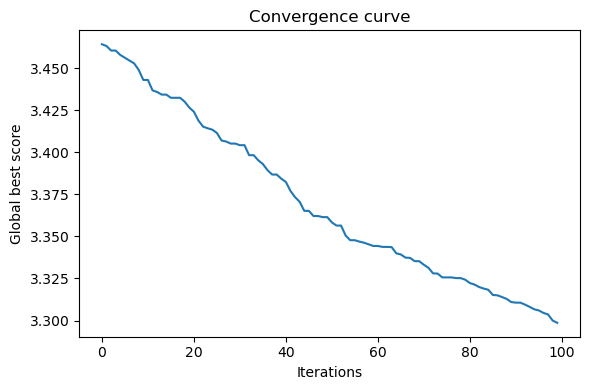

In [147]:
plt.figure(figsize= (6, 4))
plt.plot(convergence)
plt.title("Convergence curve")
plt.xlabel("Iterations")
plt.ylabel("Global best score")
plt.tight_layout()
plt.show()

In [153]:
g_best_p_2d = g_best_p.reshape(patch_shape)
g_best_p_2d.shape

(16, 16)

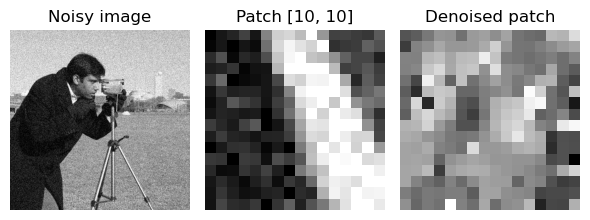

In [154]:
# reshape to 2D:
g_best_p_2d = g_best_p.reshape(patch_shape)

# visualize 
fig, axes = plt.subplots(1, 3, figsize=(6, 4))
axes[0].imshow(im_n, cmap="gray")
axes[0].set_title("Noisy image")
axes[0].axis("off")

axes[1].imshow(v_patch, cmap="gray")
axes[1].set_title("Patch [10, 10]")
axes[1].axis("off")

axes[2].imshow(g_best_p_2d, cmap="gray")
axes[2].set_title("Denoised patch")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### 3 — PSO via pyswarms
Same patch, same hyperparameters. Cross-validatation of final $\mathcal{L}_p$ against Section 2.

### 4 — Full Image Pipeline
Split 512×512 → 1024 patches of 16×16. Run PSO per patch via `multiprocessing.Pool`. Stitch back.
Boundary artefacts expected: cross-patch TV terms are dropped in the per-patch decomposition.

### 5 — Results
Per method: convergence curve, wall-clock time, final $\mathcal{L}_p$. Visual: noisy vs. denoised.